In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("accidents_weather_ca_merged.csv")
df.head()

,Start_Lat,Start_Lng,Start_Time,Severity,lat,lon,weather_main,weather_desc,temp_f,humidity,visibility,wind_speed,rain_1h
0,38.362831,-122.267197,2016-12-09 05:25:36,2,38.362831,-122.267197,Clear,clear sky,60.03,77,10000,6.91,0
1,34.022625,-118.156616,2016-07-12 10:55:04,2,34.022625,-118.156616,Clear,clear sky,65.93,40,10000,4.61,0
2,38.254620,-122.335907,2016-06-06 11:20:16,2,38.254620,-122.335907,Clear,clear sky,60.04,76,10000,6.91,0
3,38.003071,-121.337051,2016-12-17 09:25:08,2,38.003071,-121.337051,Clear,clear sky,58.32,78,10000,9.22,0
4,37.403236,-122.046913,2016-11-04 11:01:44,2,37.403236,-122.046913,Clear,clear sky,60.51,72,10000,8.05,0


In [3]:
df = df.drop(columns=['Start_Lat', 'Start_Lng'], errors='ignore')
df = df.drop(columns=['Start_Time'], errors='ignore')

df = df.dropna()

In [4]:
categorical_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [5]:
X = df.drop(columns=['Severity'])
y = df['Severity']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.74


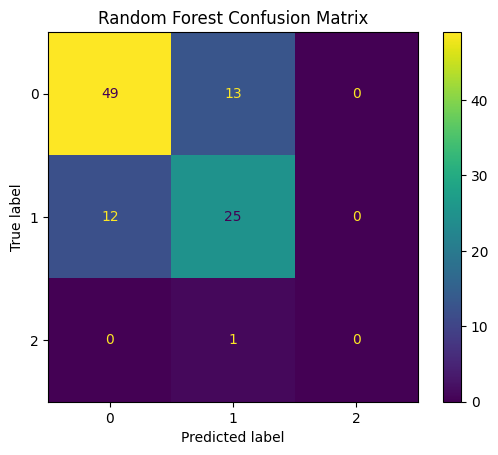

In [9]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()


In [10]:
trees = [50, 100, 200]

for t in trees:
    model = RandomForestClassifier(n_estimators=t, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Trees = {t} → Accuracy = {acc}")

Trees = 50 → Accuracy = 0.73
Trees = 100 → Accuracy = 0.74
Trees = 200 → Accuracy = 0.74


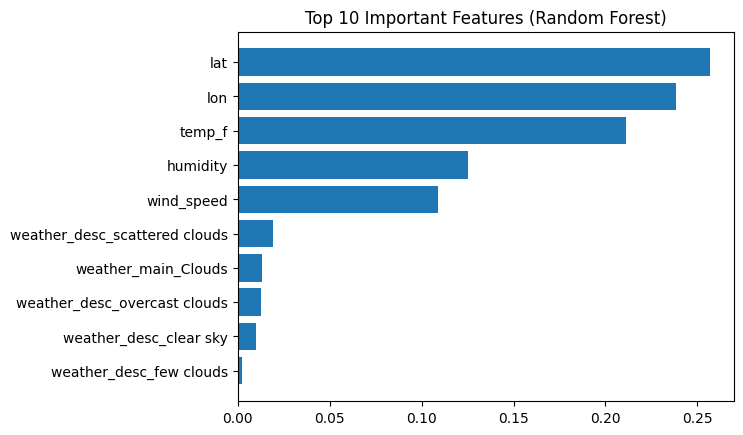

In [11]:
importances = rf.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Top 10 Important Features (Random Forest)")
plt.show()